In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from scipy.stats import chi2_contingency

In [14]:
df = pd.read_csv('Credit_Risk_Train_data.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [16]:
df['Loan_Status'] = df['Loan_Status'].astype('object')

In [17]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [18]:
uniqueness = df.nunique(dropna=False).sort_values(ascending=False)
print(uniqueness)

Loan_ID              614
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           204
Loan_Amount_Term      11
Dependents             5
Gender                 3
Married                3
Self_Employed          3
Credit_History         3
Property_Area          3
Education              2
Loan_Status            2
dtype: int64


In [19]:
n_rows = len(df)
unique_cols = [c for c in df.columns if df[c].nunique(dropna=False) == n_rows]
print(unique_cols)
near_unique_cols = [c for c in df.columns if df[c].nunique(dropna=False) > 0.95 * n_rows ]
print(near_unique_cols)

['Loan_ID']
['Loan_ID']


In [20]:
threshold = 0.75 * len(df)
cols_with_majority_same = [col for col in df.columns if df[col].value_counts(dropna=False).max() >= threshold]
print("\
Columns with 75%+ same values:")
print(cols_with_majority_same)

Columns with 75%+ same values:
['Gender', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History']


In [22]:
df=df.drop(columns=['Loan_ID'])
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [23]:
# Find duplicate rows
duplicates = df[df.duplicated()]

# Count of duplicates
print(f"Total duplicates: {duplicates.shape[0]}")

Total duplicates: 0


In [27]:
df.isna().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [25]:
def imputenull(df):
    for col in df.columns:
        if col in df.select_dtypes(include=['float64', 'int64','int32']).columns:
            if df[col].isna().any() and df[col].skew()<3:
                df[col] = df[col].fillna(df[col].mean())
            else:
                df[col] = df[col].fillna(df[col].median())
        else:
            if df[col].isna().any():
                df[col] = df[col].fillna(df[col].mode()[0])
                #data[col] = data[col].fillna(data[col].value_counts().index[0])


imputenull(df)

In [26]:
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].astype('object')
df['Credit_History'] = df['Credit_History'].astype('object')

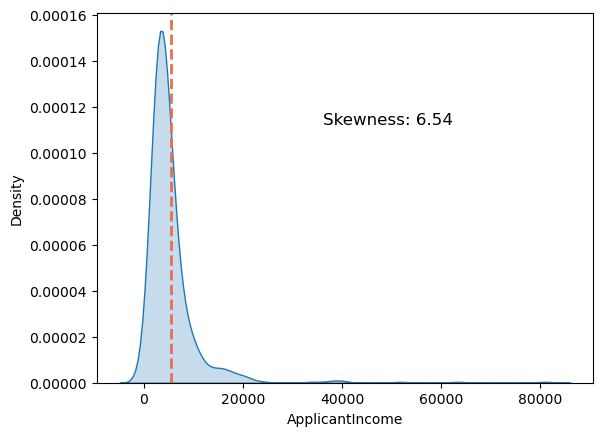

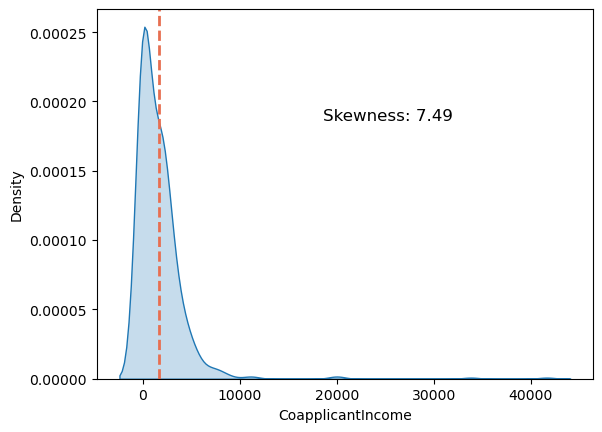

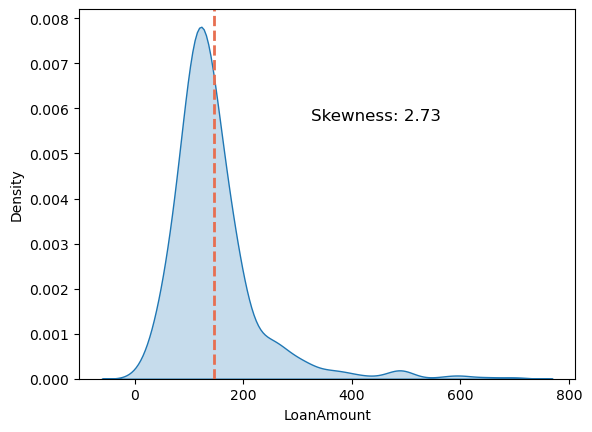

In [28]:
for col in df.select_dtypes(include=['number']).columns:
    sns.kdeplot(df[col], fill=True)
    plt.axvline(df[col].mean(), color='#e76f51', linestyle='--', linewidth=2)
    plt.text(plt.xlim()[1]*0.4, plt.ylim()[1]*0.7, f'Skewness: {df[col].skew():.2f}', color='black', fontsize=12)
    plt.show()

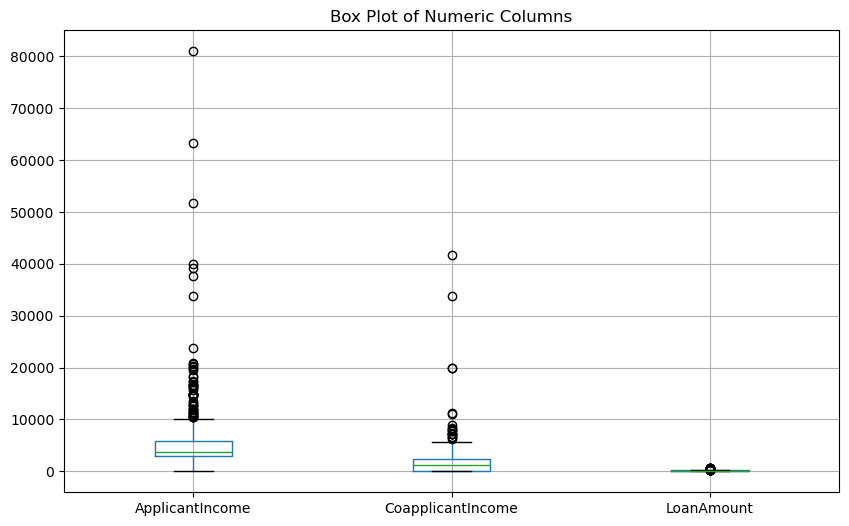

In [29]:
numeric_cols = df.select_dtypes(include=['float64', 'int64','int32']).columns
# Plot box plots for each numeric column
plt.figure(figsize=(10, 6))
df[numeric_cols].boxplot()
plt.title('Box Plot of Numeric Columns')
plt.show()

In [36]:
numeric_cols = df.select_dtypes(include=['float64', 'int64','int32']).columns
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

outliers_summary = {}
for col in numeric_cols:
    outliers = detect_outliers(df, col)
    outliers_summary[col] = len(outliers)

print("Outliers in numeric columns:")
print(outliers_summary)

Outliers in numeric columns:
{'ApplicantIncome': 1, 'CoapplicantIncome': 0, 'LoanAmount': 0}


In [35]:
for i in outliers_summary.keys():
    if outliers_summary[i] > 0:
        outliers = detect_outliers(df,i)
        df[i][outliers.index] = np.median(df[i])

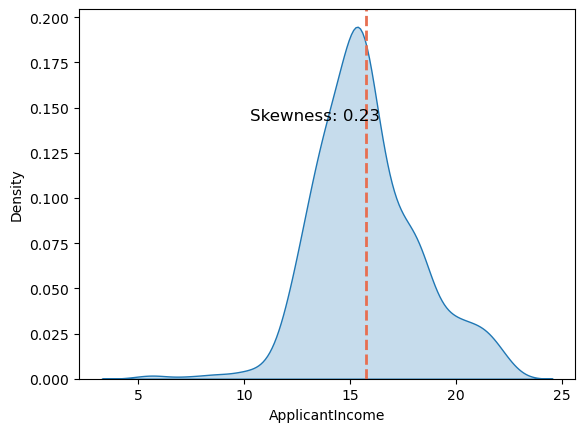

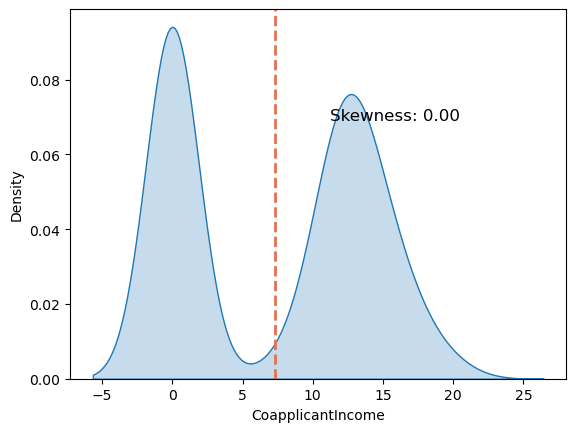

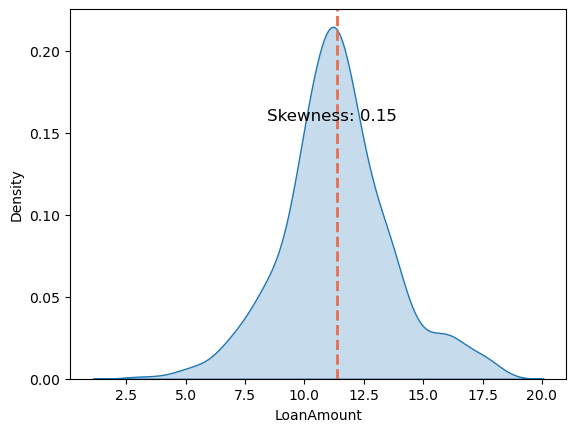

In [40]:
for col in df.select_dtypes(include=['number']).columns:
    sns.kdeplot(df[col], fill=True)
    plt.axvline(df[col].mean(), color='#e76f51', linestyle='--', linewidth=2)
    plt.text(plt.xlim()[1]*0.4, plt.ylim()[1]*0.7, f'Skewness: {df[col].skew():.2f}', color='black', fontsize=12)
    plt.show()

In [51]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,18.017473,0.000000,12.100089,360.0,1.0,2,1
1,1,1,1,0,0,16.610522,11.467457,11.313708,360.0,1.0,0,0
2,1,1,0,0,1,14.422496,0.000000,8.124038,360.0,1.0,2,1
3,1,1,0,1,0,13.720654,13.310098,10.954451,360.0,1.0,2,1
4,1,0,0,0,0,18.171206,0.000000,11.874342,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,14.260431,0.000000,8.426150,360.0,1.0,0,1
610,1,1,3+,0,0,16.013010,0.000000,6.324555,180.0,1.0,0,1
611,1,1,1,0,0,20.059821,6.214465,15.905974,360.0,1.0,2,1
612,1,1,2,0,0,19.646281,0.000000,13.674794,360.0,1.0,2,1


In [39]:
df['ApplicantIncome'] = np.cbrt(df['ApplicantIncome'])
df['CoapplicantIncome'] = np.cbrt(df['CoapplicantIncome'])
df['LoanAmount'] = np.sqrt(df['LoanAmount'])

<Axes: >

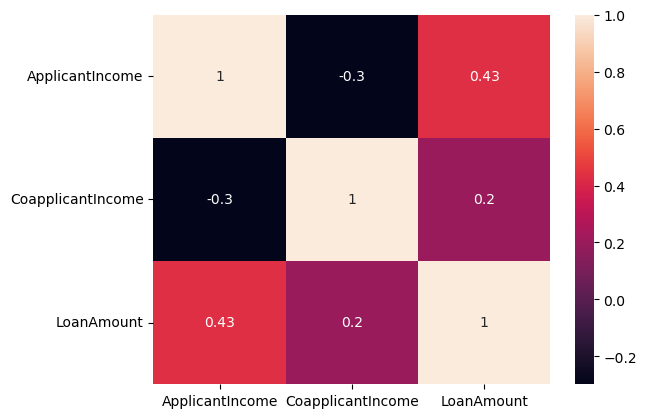

In [42]:
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)

In [57]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,379,0,100,9,2,2,1
1,1,1,1,0,0,309,61,81,9,2,0,0
2,1,1,0,0,1,139,0,26,9,2,2,1
3,1,1,0,1,0,90,161,73,9,2,2,1
4,1,0,0,0,0,384,0,94,9,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,125,0,29,9,2,0,1
610,1,1,3,0,0,278,0,7,5,2,0,1
611,1,1,1,0,0,434,3,163,9,2,2,1
612,1,1,2,0,0,425,0,133,9,2,2,1


In [56]:
le = LabelEncoder()
cols=['Gender','Married','Dependents','Education','Self_Employed','ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term',
      'Credit_History','Property_Area','Loan_Status']
for col in cols:
    df[col] = le.fit_transform(df[col])
print(df)

     Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0         1        0           0          0              0              379   
1         1        1           1          0              0              309   
2         1        1           0          0              1              139   
3         1        1           0          1              0               90   
4         1        0           0          0              0              384   
..      ...      ...         ...        ...            ...              ...   
609       0        0           0          0              0              125   
610       1        1           3          0              0              278   
611       1        1           1          0              0              434   
612       1        1           2          0              0              425   
613       0        0           0          0              1              309   

     CoapplicantIncome  LoanAmount  Loan_Amount_Ter

In [58]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["Feature"] = df.columns
vif_df["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]

print(vif_df)

              Feature        VIF
0              Gender   6.335570
1             Married   3.874554
2          Dependents   1.845816
3           Education   1.306454
4       Self_Employed   1.188001
5     ApplicantIncome   6.230984
6   CoapplicantIncome   2.361392
7          LoanAmount   8.397149
8    Loan_Amount_Term  12.135287
9      Credit_History   7.964102
10      Property_Area   2.595725
11        Loan_Status   4.462581


In [59]:
# Define X, y
y = df['Loan_Status']
X = df.drop(columns=['Loan_Status'])

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [61]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Gender             614 non-null    int64
 1   Married            614 non-null    int64
 2   Dependents         614 non-null    int64
 3   Education          614 non-null    int64
 4   Self_Employed      614 non-null    int64
 5   ApplicantIncome    614 non-null    int64
 6   CoapplicantIncome  614 non-null    int64
 7   LoanAmount         614 non-null    int64
 8   Loan_Amount_Term   614 non-null    int64
 9   Credit_History     614 non-null    int64
 10  Property_Area      614 non-null    int64
dtypes: int64(11)
memory usage: 52.9 KB


In [62]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [63]:
# 5. Standard Scaler (Z-score) features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[1.        , 0.        , 0.        , ..., 0.9       , 1.        ,
        1.        ],
       [1.        , 1.        , 0.33333333, ..., 0.9       , 1.        ,
        0.        ],
       [1.        , 1.        , 0.        , ..., 0.9       , 1.        ,
        1.        ],
       ...,
       [1.        , 1.        , 0.33333333, ..., 0.9       , 1.        ,
        1.        ],
       [1.        , 1.        , 0.66666667, ..., 0.9       , 1.        ,
        1.        ],
       [0.        , 0.        , 0.        , ..., 0.9       , 0.        ,
        0.5       ]], shape=(614, 11))

In [64]:
X_train.shape

(429, 11)

In [65]:
X_test.shape

(185, 11)

In [66]:
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [67]:
# Baseline logistic regression model
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)

# Make predictions
y_pred = logreg.predict(X_test)
y_pred

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0])

In [68]:
y_pred_proba = logreg.predict_proba(X_test)[:,1]
y_pred_proba

array([0.75784163, 0.46716432, 0.83944707, 0.80599195, 0.73268054,
       0.86071696, 0.84951347, 0.84944874, 0.78724106, 0.89951334,
       0.2939098 , 0.81656204, 0.85542361, 0.82446583, 0.94802185,
       0.64043849, 0.75082033, 0.85090526, 0.84005199, 0.80983342,
       0.74750905, 0.89958298, 0.7972762 , 0.79300127, 0.89308688,
       0.83260934, 0.83236726, 0.68052815, 0.74334358, 0.87927842,
       0.89053691, 0.94056486, 0.82360406, 0.84202334, 0.79363015,
       0.09297458, 0.86043831, 0.89388428, 0.86045814, 0.87786398,
       0.73667424, 0.86435958, 0.8359955 , 0.8447771 , 0.80177678,
       0.83192041, 0.62605569, 0.24775399, 0.16472109, 0.18800069,
       0.25710027, 0.75649093, 0.24256511, 0.77695085, 0.86117495,
       0.77945282, 0.83151154, 0.79495423, 0.16952288, 0.81399325,
       0.15457882, 0.63662112, 0.20534037, 0.86551897, 0.87321566,
       0.80143515, 0.90083567, 0.92315585, 0.91432244, 0.78310562,
       0.13344039, 0.86073703, 0.84575767, 0.87053967, 0.26551

# After modelling

In [69]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

In [71]:
from sklearn.linear_model import LassoCV

In [72]:
# 11. Lasso and Ridge (with cross-validation)
lasso = LassoCV(cv=5).fit(X_train, y_train)
ridge = RidgeCV(cv=5).fit(X_train, y_train)
print('Best Lasso alpha:', lasso.alpha_)
print('Best Ridge alpha:', ridge.alpha_)

Best Lasso alpha: 0.009092825257166896
Best Ridge alpha: 10.0


In [73]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge

In [74]:

# Run Lasso and Ridge with best alpha
best_lasso = Lasso(alpha=lasso.alpha_, max_iter=1000)
best_lasso.fit(X_train, y_train)
y_pred_lasso = best_lasso.predict(X_test)

best_ridge = Ridge(alpha=ridge.alpha_, max_iter=1000)
best_ridge.fit(X_train, y_train)
y_pred_ridge = best_ridge.predict(X_test)

In [75]:
print("\n=== 10. MODEL ANALYSIS ===")
#Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': logreg.coef_[0],
    'abs_coefficient': np.abs(logreg.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("Feature Importance (Coefficients):")
print("-" * 40)
for _, row in feature_importance.iterrows():
    sign = "+" if row['coefficient'] > 0 else "-"
    print(f"{sign} {row['feature']:15}: {row['coefficient']:7.3f}")


=== 10. MODEL ANALYSIS ===
Feature Importance (Coefficients):
----------------------------------------
+ Credit_History :   1.561
+ Married        :   0.532
- Gender         :  -0.471
+ Dependents     :   0.161
- Education      :  -0.143
+ Loan_Amount_Term:   0.104
+ Property_Area  :   0.080
+ Self_Employed  :   0.039
- LoanAmount     :  -0.008
+ CoapplicantIncome:   0.004
+ ApplicantIncome:   0.002


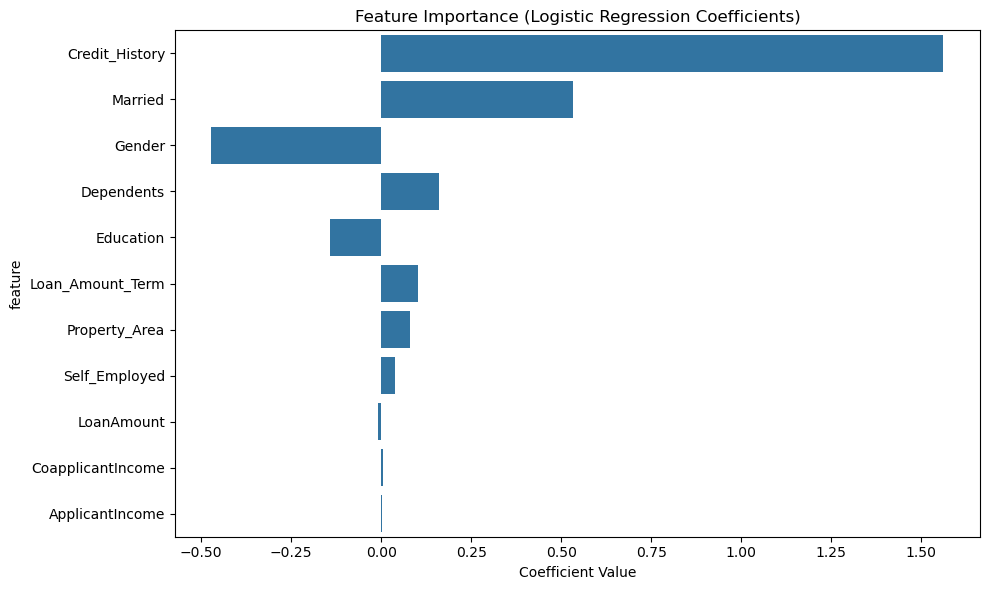

In [76]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='coefficient', y='feature')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [77]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [78]:
X_train.shape

(429, 11)

In [79]:
X_test.shape

(185, 11)

In [80]:
# Model evaluation metrics
def evaluate_model(y_true, y_pred, y_pred_proba, set_name="Test"):
    accuracy = np.mean(y_true == y_pred)
    precision = np.sum((y_pred == 1) & (y_true == 1)) / np.sum(y_pred == 1)
    recall = np.sum((y_pred == 1) & (y_true == 1)) / np.sum(y_true == 1)
    f1 = 2 * (precision * recall) / (precision + recall)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    metrics = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }
    
    print(f"\n{set_name} Set Performance:")
    print("-" * 30)
    for metric, value in metrics.items():
        print(f"{metric:12}: {value:.4f}")
    
    return metrics

In [81]:
y_pred

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0])

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

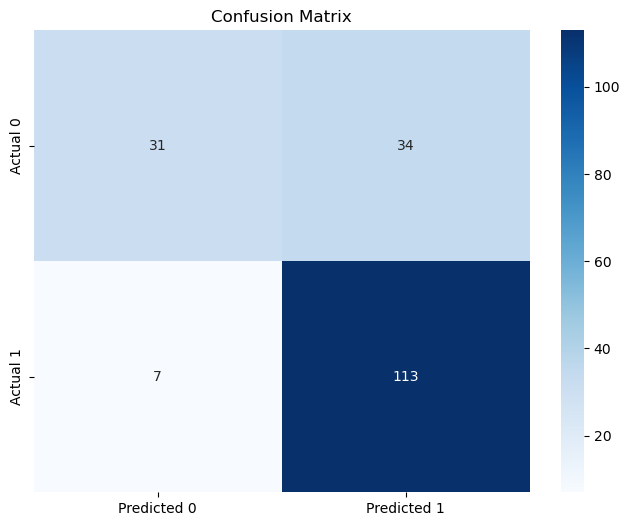

In [83]:
# 10.3 Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('Confusion Matrix')
plt.show()

Loan_Status
1    422
0    192
Name: count, dtype: int64

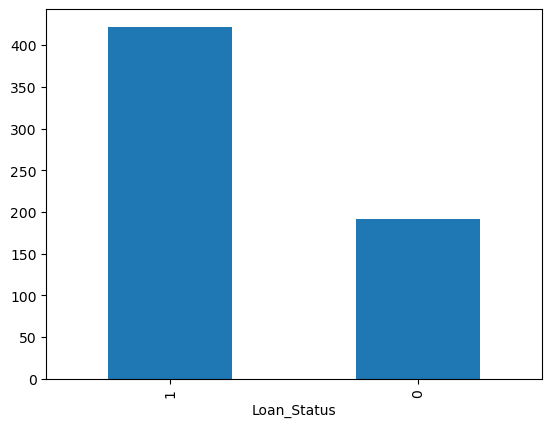

In [84]:
y.value_counts().plot(kind='bar')
y.value_counts()

In [85]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42,sampling_strategy=1)
X_resampled, y_resampled = smote.fit_resample(X, y)

Loan_Status
1    422
0    422
Name: count, dtype: int64

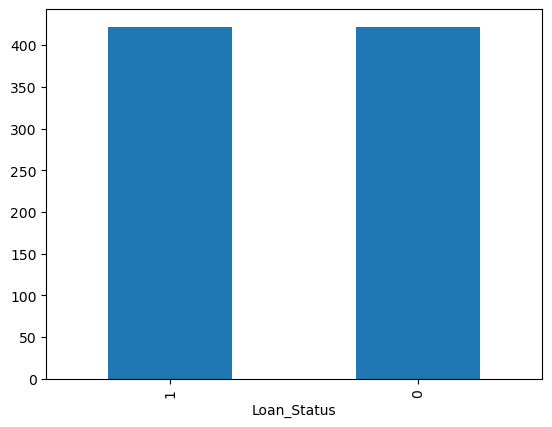

In [86]:
y_resampled.value_counts().plot(kind='bar')
y_resampled.value_counts()

In [90]:
from imblearn.under_sampling import RandomUnderSampler

In [91]:
RandomUnderSampler = RandomUnderSampler(random_state=42,sampling_strategy=1)
X_resampled, y_resampled = RandomUnderSampler.fit_resample(X, y)

Loan_Status
0    192
1    192
Name: count, dtype: int64

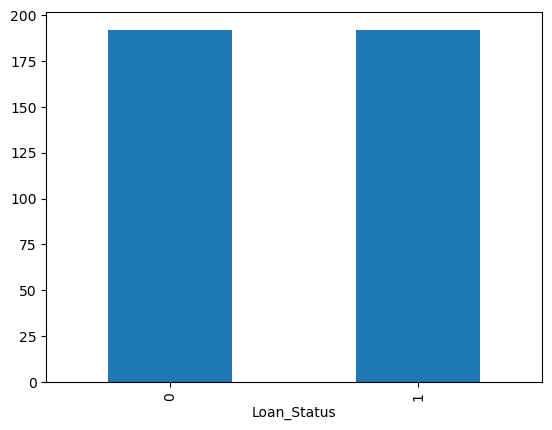

In [92]:
y_resampled.value_counts().plot(kind='bar')
y_resampled.value_counts()